# Experiment 1: Baseline model

Bag of Words (10,000 features) + Random Forest, tracked in MLflow.
Start the local tracking server first:
`mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db --artifacts-destination ./mlartifacts`

In [1]:
import os

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from src.data.text_cleaning import preprocess_comment

mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI', 'http://127.0.0.1:5000'))
DATA_URL = 'https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv'

In [2]:
# Smoke test: if this logs without errors, the tracking server is reachable
with mlflow.start_run(run_name='connection_test'):
    mlflow.log_param('param1', 15)
    mlflow.log_metric('metric1', 0.89)

2026/09/11 11:02:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run connection_test at: http://127.0.0.1:5000/#/experiments/0/runs/27cc2e7e63c440a2ba4ab92f0c69ac53.


2026/09/11 11:02:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


In [3]:
df = pd.read_csv(DATA_URL)
df = df.dropna().drop_duplicates()
df = df[df['clean_comment'].str.strip() != '']
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [4]:
# Saved once so later experiments load clean text instead of re-running preprocessing
df.to_csv('reddit_preprocessing.csv', index=False)

In [5]:
vectorizer = CountVectorizer(max_features=10000)
# Kept sparse: the original notebook's dense .toarray() copy needs about 3 GB of RAM
X = vectorizer.fit_transform(df['clean_comment'])
y = df['category']
X.shape

(36793, 10000)

2026/09/11 11:02:42 INFO mlflow.tracking.fluent: Experiment with name 'Exp 1 - RF Baseline' does not exist. Creating a new experiment.


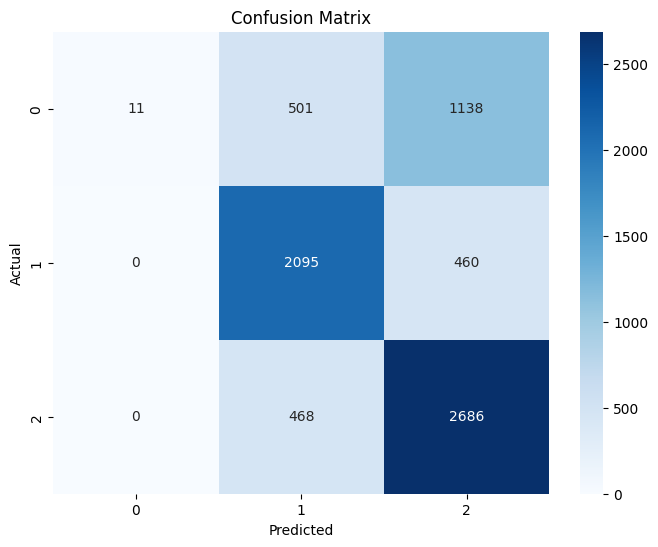

2026/09/11 11:02:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/09/11 11:02:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/09/11 11:02:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run RandomForest_Baseline_TrainTestSplit at: http://127.0.0.1:5000/#/experiments/1/runs/bcec3e41fc3244a6834a94caabead870.


2026/09/11 11:02:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Accuracy: 0.6512


In [6]:
mlflow.set_experiment('Exp 1 - RF Baseline')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

with mlflow.start_run(run_name='RandomForest_Baseline_TrainTestSplit'):
    mlflow.set_tags({
        'experiment_type': 'baseline',
        'model_type': 'RandomForestClassifier',
        'description': 'Baseline RandomForest with Bag of Words and a simple train-test split',
    })

    n_estimators, max_depth = 200, 15
    mlflow.log_params({
        'vectorizer_type': 'CountVectorizer',
        'vectorizer_max_features': vectorizer.max_features,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
    })

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric('accuracy', accuracy)
    for label, metrics in classification_report(y_test, y_pred, output_dict=True).items():
        if isinstance(metrics, dict):
            mlflow.log_metrics({f'{label}_{name}': value for name, value in metrics.items()})

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    mlflow.sklearn.log_model(model, 'random_forest_model')
    mlflow.log_artifact('reddit_preprocessing.csv')

print(f'Accuracy: {accuracy:.4f}')

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.01      0.01      1650
           0       0.68      0.82      0.75      2555
           1       0.63      0.85      0.72      3154

    accuracy                           0.65      7359
   macro avg       0.77      0.56      0.49      7359
weighted avg       0.73      0.65      0.57      7359



Negative-class recall is near zero: the model almost never predicts -1.
That is the class-imbalance problem the next experiments work on.